# Phase 1: Exploratory Data Analysis & Descriptive Analytics

This notebook loads the local sample Parquet dataset (`data/sample/binance_sample.parquet`), performs descriptive profiling across unique symbols, and generates **5 key visualizations** to understand cryptocurrency market behaviors.

### Architectural & Preprocessing Decisions:
1. **Polars vs. Pandas**: Polars is used for core data processing due to its speed (written in Rust) and lazy evaluation engine. It handles millions of observations without triggering memory leaks or out-of-memory (OOM) errors.
2. **Data Normalization**: Raw Binance datasets contain high-frequency prices in nominal USD levels. We convert them into relative log returns to make the data stationary.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join("..")))

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import src.config as config

# Load local sample data
print(f"Loading data from: {config.SAMPLE_PARQUET_PATH}")
df = pl.read_parquet(config.ACTIVE_DATA_PATH)
print(f"Loaded {len(df):,} rows.")

Loading sample data from: C:\Users\Quirora\Documents\GitHub\dat204m-final-project\data\sample\binance_sample.parquet
Loaded 30,659,220 rows.


## 1. Descriptive Statistics & Summary Metrics

In [2]:
# Aggregate key descriptive stats by symbol
df_summary = df.group_by("symbol").agg([
    pl.len().alias("total_observations"),
    pl.col("open_time").min().alias("start_date"),
    pl.col("open_time").max().alias("end_date"),
    pl.col("close").mean().alias("mean_price"),
    pl.col("close").std().alias("std_price"),
    pl.col("volume").mean().alias("mean_volume")
]).sort("total_observations", descending=True)

print("Top 5 most observed symbols in the sample:")
df_summary.head(5).to_pandas()

Top 5 most observed symbols in the sample:


,symbol,total_observations,start_date,end_date,mean_price,std_price,mean_volume
0,SOLUSDT,1578240,2023-06-01,2026-05-31 23:59:00,128.524280,60.993366,3043.351955
1,DOTUSDT,1578240,2023-06-01,2026-05-31 23:59:00,4.723005,2.144590,4681.171433
2,ETHUSDT,1578240,2023-06-01,2026-05-31 23:59:00,2722.117413,781.332561,304.444406
3,BCHUSDT,1578240,2023-06-01,2026-05-31 23:59:00,397.141240,129.614160,64.608909
4,LINKUSDT,1578240,2023-06-01,2026-05-31 23:59:00,14.008023,4.995482,3186.080072


## 2. Vis 1: Normalized Price Trends
We overlay normalized close price series for the top 5 assets to inspect long-term trend correlations.

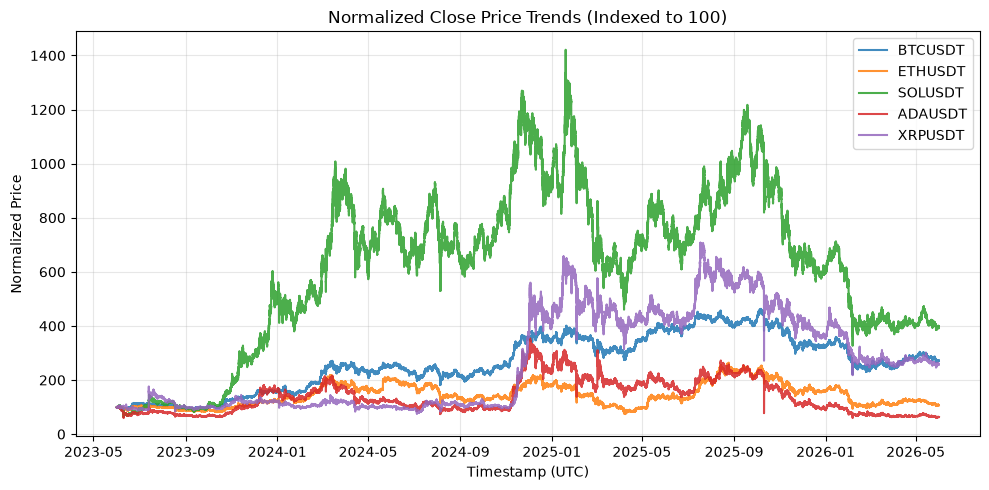

In [3]:
top_5_symbols = ["BTCUSDT", "ETHUSDT", "SOLUSDT", "ADAUSDT", "XRPUSDT"]

plt.figure(figsize=(10, 5))
for symbol in top_5_symbols:
    sym_df = df.filter(pl.col("symbol") == symbol).sort("open_time").to_pandas()
    # Scale close price to start at 100 for relative comparison
    sym_df["scaled_close"] = (sym_df["close"] / sym_df["close"].iloc[0]) * 100
    plt.plot(sym_df["open_time"], sym_df["scaled_close"], label=symbol, alpha=0.85)

plt.title("Normalized Close Price Trends (Indexed to 100)")
plt.xlabel("Timestamp (UTC)")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Vis 2: Return Distributions
We inspect the log return distribution of the configured target symbol to evaluate normality (skewness/kurtosis).

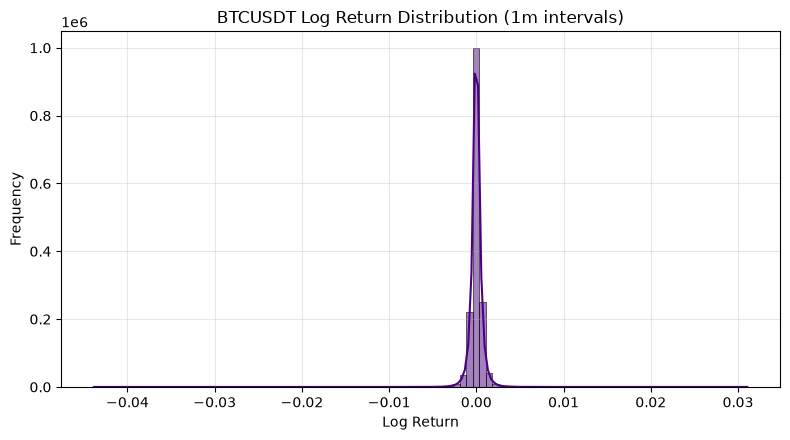

Skewness: -0.6343
Kurtosis (excess): 81.8972


In [4]:
target_df = df.filter(pl.col("symbol") == config.TARGET_SYMBOL).sort("open_time").to_pandas()
target_df["log_return"] = np.log(target_df["close"] / target_df["close"].shift(1))

plt.figure(figsize=(8, 4.5))
sns.histplot(target_df["log_return"].dropna(), bins=100, kde=True, color="indigo")
plt.title(f"{config.TARGET_SYMBOL} Log Return Distribution (1m intervals)")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Skewness: {target_df['log_return'].skew():.4f}")
print(f"Kurtosis (excess): {target_df['log_return'].kurtosis():.4f}")

## 4. Vis 3: Volatility Analysis
We calculate rolling standard deviation of log returns (30-period window) to inspect volatility clustering regimes.

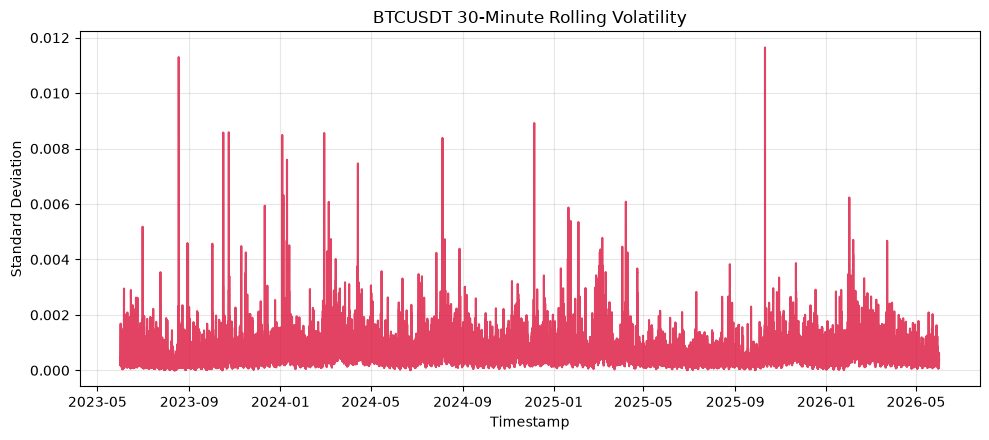

In [5]:
target_df["rolling_vol"] = target_df["log_return"].rolling(window=30).std()

plt.figure(figsize=(10, 4.5))
plt.plot(target_df["open_time"], target_df["rolling_vol"], color="crimson", alpha=0.8)
plt.title(f"{config.TARGET_SYMBOL} 30-Minute Rolling Volatility")
plt.xlabel("Timestamp")
plt.ylabel("Standard Deviation")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Vis 4: Average Volume by Hour of Day
We analyze seasonal trading activity based on the hour of day.

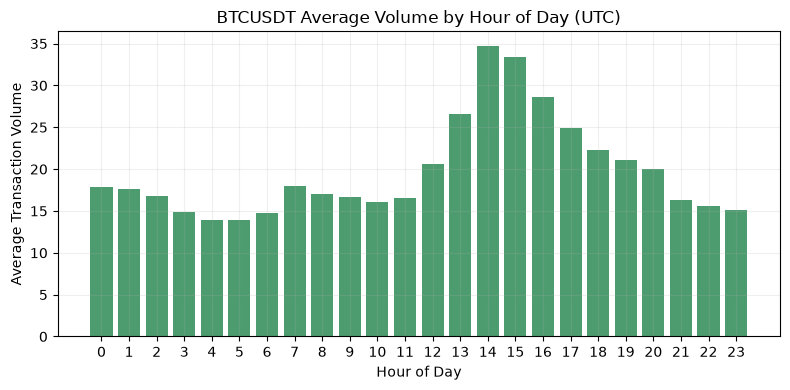

In [6]:
target_df["hour"] = pd.to_datetime(target_df["open_time"]).dt.hour
hourly_volume = target_df.groupby("hour")["volume"].mean()

plt.figure(figsize=(8, 4))
plt.bar(hourly_volume.index, hourly_volume.values, color="seagreen", alpha=0.85)
plt.title(f"{config.TARGET_SYMBOL} Average Volume by Hour of Day (UTC)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Transaction Volume")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Vis 5: Asset Return Correlation Heatmap
We calculate return correlations across top cryptocurrency assets to understand system co-movements.

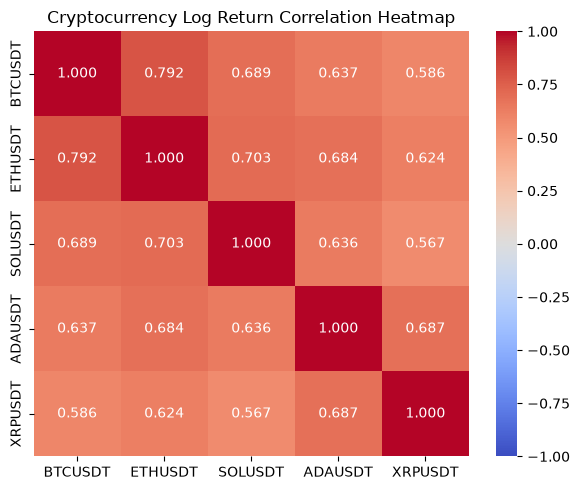

In [7]:
returns_dict = {}
for symbol in top_5_symbols:
    sym_df = df.filter(pl.col("symbol") == symbol).sort("open_time").to_pandas()
    sym_df["log_return"] = np.log(sym_df["close"] / sym_df["close"].shift(1))
    returns_dict[symbol] = sym_df.set_index("open_time")["log_return"]

corr_df = pd.DataFrame(returns_dict).dropna()
plt.figure(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".3f", vmin=-1, vmax=1)
plt.title("Cryptocurrency Log Return Correlation Heatmap")
plt.tight_layout()
plt.show()